# Computations Package Overview

Hands-on tour of `pysatl_core.distributions.computations`.

The package provides a **computation pipeline** that automatically derives missing
distribution characteristics (PDF, CDF, PPF, PMF) from the ones a distribution
already knows analytically.

For example, if you only implement a **PDF**, the pipeline can:
- integrate it numerically to get a **CDF** (`pdf -> cdf`)
- invert the CDF via bisection to get a **PPF** (`cdf -> ppf`)

| Module | Role |
|---|---|
| `computation.py` | Core primitives: `FittedComputationMethod`, `FitterMethod`, `EvaluatorMethod`, `AnalyticalComputation` |
| `options.py` | Option descriptors: `CharacteristicOption`, `ComputationOption`, `EdgeOptionsDescriptor` |
| `descriptors.py` | Rich metadata wrappers: `FitterDescriptor`, `EvaluatorDescriptor` |
| `continuous.py` | Built-in continuous fitters: `pdf→cdf`, `cdf→pdf`, `cdf→ppf`, `ppf→cdf` |
| `discrete.py` | Built-in discrete fitters: `pmf→cdf`, `cdf→pmf`, `cdf→ppf`, `ppf→cdf` |
| `registry.py` | `FitterRegistry` — stores and looks up fitter descriptors |
| `_utils.py` | Internal helpers: `resolve`, `estimate_support_bounds`, `build_head_table`, `build_tail_table` |

In [1]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np

from pysatl_core.distributions.computations.computation import (
    AnalyticalComputation,
    EvaluatorMethod,
    FittedComputationMethod,
    FitterMethod,
)
from pysatl_core.distributions.computations.continuous import (
    _build_pdf_to_cdf_1C,
    _build_ppf_to_cdf_1C,
    _fit_cdf_to_pdf_1C,
    _fit_cdf_to_ppf_1C,
    _fit_pdf_to_cdf_1C,
    _fit_ppf_to_cdf_1C,
)
from pysatl_core.distributions.computations.descriptors import FitterDescriptor
from pysatl_core.distributions.computations.discrete import (
    _fit_cdf_to_pmf_1D,
    _fit_cdf_to_ppf_1D,
    _fit_pmf_to_cdf_1D,
)
from pysatl_core.distributions.computations.options import (
    CharacteristicOption,
    ComputationOption,
    EdgeOptionsDescriptor,
)
from pysatl_core.distributions.computations.registry import FitterRegistry, fitter_registry
from pysatl_core.distributions.distribution import _KEEP, Distribution
from pysatl_core.distributions.strategies import DefaultComputationStrategy
from pysatl_core.distributions.support import (
    ContinuousSupport,
    ExplicitTableDiscreteSupport,
    IntegerLatticeDiscreteSupport,
)
from pysatl_core.types import CharacteristicName, EuclideanDistributionType, Kind

## Setup: minimal standalone distribution

`Distribution` is abstract — it requires implementing `_clone_with_strategies()`.
The stub below satisfies the ABC contract and is used throughout this notebook.

In [2]:
class SimpleDistribution(Distribution):
    """Minimal concrete Distribution for notebook examples."""

    def __init__(self, kind, analytical_computations, support=None, computation_strategy=None):
        super().__init__(
            distribution_type=EuclideanDistributionType(kind, 1),
            analytical_computations=analytical_computations,
            support=support,
            computation_strategy=computation_strategy,
        )

    def _clone_with_strategies(self, *, sampling_strategy=_KEEP, computation_strategy=_KEEP):
        return self  # stub — not needed for these examples


def wrap(target, func):
    """Wrap a plain callable as an AnalyticalComputation."""
    return AnalyticalComputation(target=target, func=func)

## 1. Core primitives

| Class | Role | Cacheable |
|---|---|---|
| `AnalyticalComputation` | Wraps a known formula provided by the distribution | N/A |
| `FitterMethod` | Factory: expensive precomputation → `FittedComputationMethod` | yes |
| `EvaluatorMethod` | Lightweight per-call computation, no precomputation | no |
| `FittedComputationMethod` | Ready-to-call result of a fitter | — |

All three share the same call interface once fitted/prepared: `method(x)` or `method()`.

In [3]:
# AnalyticalComputation: wraps a known formula.
# The distribution provides this directly — no fitting needed.


def normal_pdf(x, **_):
    x = np.asarray(x, dtype=float)
    return np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)


analytical_pdf = AnalyticalComputation(target=CharacteristicName.PDF, func=normal_pdf)

xs = np.linspace(-3, 3, 7)
print("AnalyticalComputation -- PDF at [-3..3]:")
print(analytical_pdf(xs).round(4))
print(f"  target = {analytical_pdf.target!r}")

AnalyticalComputation -- PDF at [-3..3]:
[0.0044 0.054  0.242  0.3989 0.242  0.054  0.0044]
  target = <CharacteristicName.PDF: 'pdf'>


In [4]:
# FittedComputationMethod: the *output* of a fitter.
# Holds precomputed state and exposes a callable interface.


def _normal_cdf_func(x, **_):
    x = np.asarray(x, dtype=float)
    return 0.5 * (1.0 + np.vectorize(math.erf)(x / math.sqrt(2)))


fitted_cdf = FittedComputationMethod(
    target=CharacteristicName.CDF,
    sources=[CharacteristicName.PDF],
    func=_normal_cdf_func,
)

print("FittedComputationMethod -- CDF at [-2, 0, 2]:")
print(fitted_cdf(np.array([-2.0, 0.0, 2.0])).round(4))
print(f"  target  = {fitted_cdf.target!r}")
print(f"  sources = {fitted_cdf.sources}")

FittedComputationMethod -- CDF at [-2, 0, 2]:
[0.0228 0.5    0.9772]
  target  = <CharacteristicName.CDF: 'cdf'>
  sources = [<CharacteristicName.PDF: 'pdf'>]


In [5]:
# FitterMethod: a factory that, given a distribution, performs expensive
# precomputation and returns a FittedComputationMethod.


def my_fitter(distribution, /, limit=200):
    """Integrates the analytical PDF to get a CDF."""
    from scipy import integrate

    pdf_fn = distribution.query_method(CharacteristicName.PDF)

    def _cdf(x, **opts):
        x_arr = np.atleast_1d(np.asarray(x, dtype=float))
        return np.array(
            [
                integrate.quad(
                    lambda t: float(np.asarray(pdf_fn(np.array([t])), dtype=float).flat[0]),
                    -np.inf,
                    xi,
                    limit=limit,
                )[0]
                for xi in x_arr
            ]
        )

    return FittedComputationMethod(
        target=CharacteristicName.CDF, sources=[CharacteristicName.PDF], func=_cdf
    )


fitter_method = FitterMethod(
    target=CharacteristicName.CDF, sources=[CharacteristicName.PDF], fitter=my_fitter
)
print(f"FitterMethod.cacheable = {fitter_method.cacheable}")

# Build a distribution that has an analytical PDF
normal_distr = SimpleDistribution(
    kind=Kind.CONTINUOUS,
    analytical_computations={CharacteristicName.PDF: analytical_pdf},
    support=ContinuousSupport(),
)

# Fit the fitter to the distribution -> get a FittedComputationMethod
fitted = fitter_method.fit(normal_distr)
print("Fitted CDF at [-1, 0, 1]:", fitted(np.array([-1.0, 0.0, 1.0])).round(4))

FitterMethod.cacheable = True
Fitted CDF at [-1, 0, 1]: [0.1587 0.5    0.8413]


In [6]:
# EvaluatorMethod: lightweight, called on every query, no precomputation.


def my_evaluator(distribution, x, **opts):
    """Returns PDF values directly (no fitting needed)."""
    pdf_fn = distribution.query_method(CharacteristicName.PDF)
    return np.asarray(pdf_fn(x), dtype=float)


evaluator_method = EvaluatorMethod(
    target=CharacteristicName.PDF, sources=[CharacteristicName.PDF], evaluator=my_evaluator
)
print(f"EvaluatorMethod.cacheable = {evaluator_method.cacheable}")

result = evaluator_method.evaluate(normal_distr, np.array([0.0]))
print(f"PDF(0) via evaluator = {result}  (expected ~0.398942)")

EvaluatorMethod.cacheable = False
PDF(0) via evaluator = [0.39894228]  (expected ~0.398942)


## 2. Option taxonomy

| Class | Affects | Cache key? | Example |
|---|---|---|---|
| `CharacteristicOption` | *Meaning* of the result | yes | `eps` (tail threshold for PPF) |
| `ComputationOption` | *Algorithm* accuracy/speed | no | `max_iter`, `limit` |

Both are declared on `FitterDescriptor` / `EvaluatorDescriptor` and resolved at call time.

**Key insight**: two calls with different `CharacteristicOption` values produce **different cache
entries**, while different `ComputationOption` values do not — because computation options only
affect the accuracy of the fitting step, not the semantic meaning of the result.

In [7]:
eps_option = CharacteristicOption(
    name="eps",
    type=float,
    default=1e-6,
    description="Tail probability threshold for support bound estimation.",
    validate=lambda v: 0 < v < 0.5,
)

max_iter_option = ComputationOption(
    name="max_iter",
    type=int,
    default=60,
    description="Maximum bisection iterations.",
    validate=lambda v: v > 0,
)

# Resolve from a kwargs dict (pops recognised keys, leaves the rest)
kwargs = {"eps": "0.01", "max_iter": "100", "unrelated_key": True}
resolved_eps = eps_option.resolve(kwargs)
resolved_iter = max_iter_option.resolve(kwargs)

print(f"resolved eps      = {resolved_eps}  ({type(resolved_eps).__name__})")
print(f"resolved max_iter = {resolved_iter}  ({type(resolved_iter).__name__})")
print(f"remaining kwargs  = {kwargs}")

resolved eps      = 0.01  (float)
resolved max_iter = 100  (int)
remaining kwargs  = {'unrelated_key': True}


In [8]:
# Validation errors are raised eagerly at resolve time.
for bad, opt in [
    ({"eps": 0.9}, eps_option),  # fails: 0.9 >= 0.5
    ({"max_iter": -5}, max_iter_option),  # fails: -5 <= 0
]:
    try:
        opt.resolve(bad)
    except ValueError as e:
        print(f"ValueError (expected): {e}")

ValueError (expected): Option 'eps': value 0.9 failed validation.
ValueError (expected): Option 'max_iter': value -5 failed validation.


In [9]:
# EdgeOptionsDescriptor: compact graph-level form.
# Carries only option metadata (no callable), cheap to attach to every graph edge.

edge_desc = EdgeOptionsDescriptor(
    name="cdf_to_ppf_1C",
    characteristic_options=(eps_option,),
    computation_options=(max_iter_option,),
)

print("All options:", [o.name for o in edge_desc.options])
print("Characteristic options:", [o.name for o in edge_desc.characteristic_options])
print("Computation options:", [o.name for o in edge_desc.computation_options])

# with_values: validate and freeze into a ResolvedEdgeOptions
resolved = edge_desc.with_values(eps=1e-4, max_iter=30)
print("Resolved values:", resolved.values)

All options: ['eps', 'max_iter']
Characteristic options: ['eps']
Computation options: ['max_iter']
Resolved values: {'eps': 0.0001, 'max_iter': 30}


## 3. Continuous fitters

| Fitter | Conversion | Algorithm |
|---|---|---|
| `pdf_to_cdf_1C` | PDF → CDF | Segment-wise `scipy.integrate.quad` |
| `cdf_to_pdf_1C` | CDF → PDF | Five-point central finite difference |
| `cdf_to_ppf_1C` | CDF → PPF | Vectorised bisection |
| `ppf_to_cdf_1C` | PPF → CDF | Root inversion via `scipy.optimize.brentq` |

Each fitter is a plain function `fit_*(distribution, /, **options) -> FittedComputationMethod`.
A corresponding `_build_*()` factory returns a `FitterDescriptor` with full metadata.

In [10]:
# Build test distributions — each has exactly one analytical characteristic.

# Logistic distribution: CDF = 1 / (1 + exp(-x))
def logistic_cdf(x, **_):
    x = np.asarray(x, dtype=float)
    return 1.0 / (1.0 + np.exp(-x))


logistic_distr = SimpleDistribution(
    kind=Kind.CONTINUOUS,
    analytical_computations={CharacteristicName.CDF: wrap(CharacteristicName.CDF, logistic_cdf)},
    support=ContinuousSupport(),
)


# Uniform[0,1]: PDF = 1 on [0,1]
def uniform_pdf_fn(x, **_):
    x = np.asarray(x, dtype=float)
    return np.where((x >= 0.0) & (x <= 1.0), 1.0, 0.0)


uniform_pdf_distr = SimpleDistribution(
    kind=Kind.CONTINUOUS,
    analytical_computations={CharacteristicName.PDF: wrap(CharacteristicName.PDF, uniform_pdf_fn)},
    support=ContinuousSupport(0, 1),
)


# Uniform[0,1]: PPF = q
def uniform_ppf_fn(q, **_):
    return np.asarray(q, dtype=float)


uniform_ppf_distr = SimpleDistribution(
    kind=Kind.CONTINUOUS,
    analytical_computations={CharacteristicName.PPF: wrap(CharacteristicName.PPF, uniform_ppf_fn)},
    support=ContinuousSupport(0, 1),
)

In [11]:
# 3.1  pdf -> cdf  (numerical integration via scipy.integrate.quad)

fitted_cdf_from_pdf = _fit_pdf_to_cdf_1C(uniform_pdf_distr)

xs = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
cdf_vals = np.asarray(fitted_cdf_from_pdf(xs), dtype=float)

print("pdf -> cdf  (Uniform[0,1])")
print(f"  x        = {xs}")
print(f"  CDF(x)   = {cdf_vals.round(4)}")
print(f"  expected = {xs}  (identity on [0,1])")

desc = _build_pdf_to_cdf_1C()
print(f"\nDescriptor {desc.name!r}")
print(f"  target  = {desc.target!r}")
print(f"  sources = {list(desc.sources)}")
print(f"  tags    = {desc.constraint_tags}")
print(f"  options = {desc.option_names()}")

pdf -> cdf  (Uniform[0,1])
  x        = [0.   0.25 0.5  0.75 1.  ]
  CDF(x)   = [0.   0.25 0.5  0.75 1.  ]
  expected = [0.   0.25 0.5  0.75 1.  ]  (identity on [0,1])

Descriptor 'pdf_to_cdf_1C'
  target  = <CharacteristicName.CDF: 'cdf'>
  sources = [<CharacteristicName.PDF: 'pdf'>]
  tags    = frozenset({'univariate', 'continuous'})
  options = ('limit',)


In [12]:
# 3.2  cdf -> pdf  (five-point central finite difference)

fitted_pdf_from_cdf = _fit_cdf_to_pdf_1C(logistic_distr)

xs = np.linspace(-3, 3, 7)
pdf_num = np.asarray(fitted_pdf_from_cdf(xs), dtype=float)
pdf_ana = np.exp(-xs) / (1.0 + np.exp(-xs)) ** 2  # logistic PDF

print("cdf -> pdf  (Logistic)")
print(f"  numerical  = {pdf_num.round(5)}")
print(f"  analytical = {pdf_ana.round(5)}")
print(f"  max err    = {np.abs(pdf_num - pdf_ana).max():.2e}")

# Effect of step size h (ComputationOption — does NOT affect cache key)
print("\nEffect of h (ComputationOption):")
for h in [1e-2, 1e-4, 1e-6, 1e-8]:
    err = np.abs(
        np.asarray(_fit_cdf_to_pdf_1C(logistic_distr, h=h)(xs), dtype=float) - pdf_ana
    ).max()
    print(f"  h={h:.0e}  max_err={err:.2e}")

cdf -> pdf  (Logistic)
  numerical  = [0.04518 0.10499 0.19661 0.25    0.19661 0.10499 0.04518]
  analytical = [0.04518 0.10499 0.19661 0.25    0.19661 0.10499 0.04518]
  max err    = 5.30e-12

Effect of h (ComputationOption):
  h=1e-02  max_err=8.33e-11
  h=1e-04  max_err=8.37e-13
  h=1e-06  max_err=1.09e-10
  h=1e-08  max_err=1.38e-08


In [13]:
# 3.3  cdf -> ppf  (vectorised bisection)

fitted_ppf = _fit_cdf_to_ppf_1C(logistic_distr)

qs = np.array([0.1, 0.25, 0.5, 0.75, 0.9])
ppf_num = np.asarray(fitted_ppf(qs), dtype=float)
ppf_ana = np.log(qs / (1.0 - qs))  # logit = logistic PPF

print("cdf -> ppf  (Logistic)")
print(f"  numerical  = {ppf_num.round(5)}")
print(f"  analytical = {ppf_ana.round(5)}")
print(f"  max err    = {np.abs(ppf_num - ppf_ana).max():.2e}")

boundary = np.asarray(fitted_ppf(np.array([0.0, 1.0])), dtype=float)
print(f"  PPF(0) = {boundary[0]}  (expected -inf)")
print(f"  PPF(1) = {boundary[1]}  (expected +inf)")

# Effect of eps (CharacteristicOption — DOES affect cache key and result meaning)
print("\nEffect of eps (CharacteristicOption — changes effective support bounds):")
for eps in [1e-3, 1e-6, 1e-9]:
    err = np.abs(
        np.asarray(_fit_cdf_to_ppf_1C(logistic_distr, eps=eps)(qs), dtype=float) - ppf_ana
    ).max()
    print(f"  eps={eps:.0e}  max_err={err:.2e}")

cdf -> ppf  (Logistic)
  numerical  = [-2.19722 -1.09861 -0.       1.09861  2.19722]
  analytical = [-2.19722 -1.09861  0.       1.09861  2.19722]
  max err    = 2.73e-11
  PPF(0) = -inf  (expected -inf)
  PPF(1) = inf  (expected +inf)

Effect of eps (CharacteristicOption — changes effective support bounds):
  eps=1e-03  max_err=2.55e-11
  eps=1e-06  max_err=2.73e-11
  eps=1e-09  max_err=2.82e-11


In [14]:
# 3.4  ppf -> cdf  (root inversion via scipy.optimize.brentq)

fitted_cdf_from_ppf = _fit_ppf_to_cdf_1C(uniform_ppf_distr)

xs = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
cdf_vals = np.asarray(fitted_cdf_from_ppf(xs), dtype=float)

print("ppf -> cdf  (Uniform[0,1])")
print(f"  x        = {xs}")
print(f"  CDF(x)   = {cdf_vals.round(4)}")
print(f"  expected = {xs}")

desc = _build_ppf_to_cdf_1C()
print(f"\nDescriptor {desc.name!r}: options = {desc.option_names()}")

ppf -> cdf  (Uniform[0,1])
  x        = [0.1 0.3 0.5 0.7 0.9]
  CDF(x)   = [0.1 0.3 0.5 0.7 0.9]
  expected = [0.1 0.3 0.5 0.7 0.9]

Descriptor 'ppf_to_cdf_1C': options = ('q_lowest', 'q_highest', 'max_iter')


In [15]:
# 3.5  Roundtrip: CDF(PPF(q)) ≈ q

ppf_fitted = _fit_cdf_to_ppf_1C(logistic_distr)
cdf_fn = logistic_distr.query_method(CharacteristicName.CDF)

qs = np.linspace(0.05, 0.95, 10)
xs_from_ppf = np.asarray(ppf_fitted(qs), dtype=float)
qs_recovered = np.array(
    [float(np.asarray(cdf_fn(np.array([x])), dtype=float).flat[0]) for x in xs_from_ppf]
)

print("Roundtrip CDF(PPF(q)) ≈ q  (Logistic)")
print(f"  q          = {qs.round(3)}")
print(f"  recovered  = {qs_recovered.round(3)}")
print(f"  max err    = {np.abs(qs_recovered - qs).max():.2e}")

Roundtrip CDF(PPF(q)) ≈ q  (Logistic)
  q          = [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
  recovered  = [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
  max err    = 3.10e-12


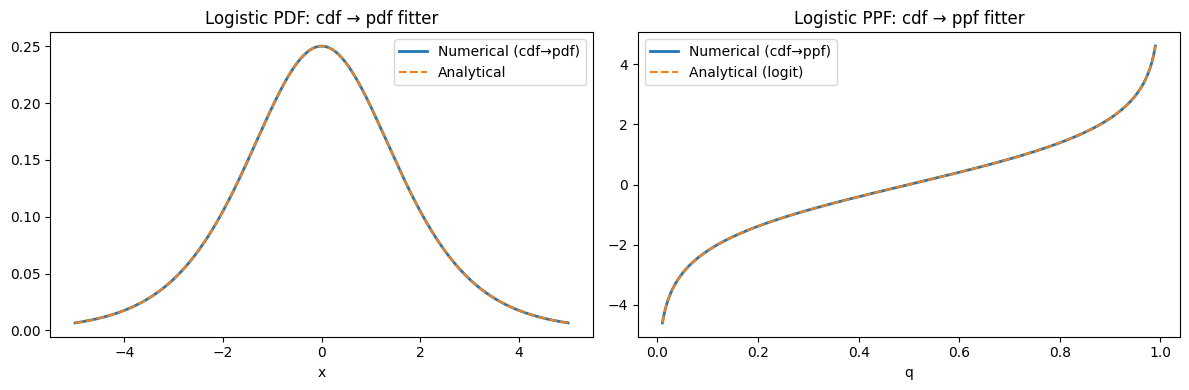

In [16]:
# 3.6  Visualisation: continuous fitters on Logistic distribution

xs_plot = np.linspace(-5, 5, 300)
qs_plot = np.linspace(0.01, 0.99, 300)

pdf_fitted_vals = np.asarray(_fit_cdf_to_pdf_1C(logistic_distr)(xs_plot), dtype=float)
ppf_fitted_vals = np.asarray(_fit_cdf_to_ppf_1C(logistic_distr)(qs_plot), dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(xs_plot, pdf_fitted_vals, label="Numerical (cdf→pdf)", lw=2)
axes[0].plot(
    xs_plot, np.exp(-xs_plot) / (1 + np.exp(-xs_plot)) ** 2, "--", label="Analytical", lw=1.5
)
axes[0].set_title("Logistic PDF: cdf → pdf fitter")
axes[0].set_xlabel("x")
axes[0].legend()

axes[1].plot(qs_plot, ppf_fitted_vals, label="Numerical (cdf→ppf)", lw=2)
axes[1].plot(qs_plot, np.log(qs_plot / (1 - qs_plot)), "--", label="Analytical (logit)", lw=1.5)
axes[1].set_title("Logistic PPF: cdf → ppf fitter")
axes[1].set_xlabel("q")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Discrete fitters

| Fitter | Conversion | Algorithm |
|---|---|---|
| `pmf_to_cdf_1D` | PMF → CDF | Prefix-sum (finite) or tail-walk (unbounded) |
| `cdf_to_pmf_1D` | CDF → PMF | Finite differences on support table |
| `cdf_to_ppf_1D` | CDF → PPF | `searchsorted` inversion on support table |
| `ppf_to_cdf_1D` | PPF → CDF | Grid probing + step-function table |

Discrete fitters require a `DiscreteSupport` attached to the distribution.
Two concrete support types:
- `ExplicitTableDiscreteSupport` — finite list of points
- `IntegerLatticeDiscreteSupport` — integer lattice `{residue + k*modulus}`, optionally bounded

The `pmf_to_cdf_1D` fitter handles three cases automatically:
1. **Finite support** — prefix-sum over the full table
2. **Left-bounded, right-unbounded** — walks rightward until tail mass < `eps`
3. **Right-bounded, left-unbounded** — walks leftward until tail mass < `eps`

In [17]:
# 4.1  pmf -> cdf  (finite support: prefix-sum)
# Distribution: support {0,1,2}, PMF = {0:0.2, 1:0.5, 2:0.3}

masses = {0.0: 0.2, 1.0: 0.5, 2.0: 0.3}


def point_pmf(x, **_):
    x = np.asarray(x, dtype=float)
    return np.vectorize(lambda xi: masses.get(float(xi), 0.0))(x)


discrete_pmf_distr = SimpleDistribution(
    kind=Kind.DISCRETE,
    analytical_computations={CharacteristicName.PMF: wrap(CharacteristicName.PMF, point_pmf)},
    support=ExplicitTableDiscreteSupport([0, 1, 2]),
)

fitted_cdf_1D = _fit_pmf_to_cdf_1D(discrete_pmf_distr)

test_xs = np.array([-0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5])
cdf_1D = np.asarray(fitted_cdf_1D(test_xs), dtype=float)

print("pmf -> cdf  ({0:0.2, 1:0.5, 2:0.3})")
for x, c in zip(test_xs, cdf_1D, strict=False):
    print(f"  CDF({x:+.1f}) = {c:.4f}")

pmf -> cdf  ({0:0.2, 1:0.5, 2:0.3})
  CDF(-0.5) = 0.0000
  CDF(+0.0) = 0.2000
  CDF(+0.5) = 0.2000
  CDF(+1.0) = 0.7000
  CDF(+1.5) = 0.7000
  CDF(+2.0) = 1.0000
  CDF(+2.5) = 1.0000


In [18]:
# 4.2  cdf -> pmf  (finite differences on CDF table)


def discrete_cdf_fn(x, **_):
    x = np.asarray(x, dtype=float)
    return np.where(x < 0, 0.0, np.where(x < 1, 0.2, np.where(x < 2, 0.7, 1.0)))


discrete_cdf_distr = SimpleDistribution(
    kind=Kind.DISCRETE,
    analytical_computations={CharacteristicName.CDF: wrap(CharacteristicName.CDF, discrete_cdf_fn)},
    support=ExplicitTableDiscreteSupport([0, 1, 2]),
)

fitted_pmf_1D = _fit_cdf_to_pmf_1D(discrete_cdf_distr)
support_pts = np.array([0.0, 1.0, 2.0])
pmf_vals = np.asarray(fitted_pmf_1D(support_pts), dtype=float)

print("cdf -> pmf  (recovered PMF at support points):")
for x, p in zip(support_pts, pmf_vals, strict=False):
    print(f"  PMF({x:.0f}) = {p:.4f}")

off_support = np.asarray(fitted_pmf_1D(np.array([-1.0, 0.5, 1.5, 3.0])), dtype=float)
print(f"Off-support values: {off_support}  (all should be 0)")

cdf -> pmf  (recovered PMF at support points):
  PMF(0) = 0.2000
  PMF(1) = 0.5000
  PMF(2) = 0.3000
Off-support values: [0. 0. 0. 0.]  (all should be 0)


In [19]:
# 4.3  cdf -> ppf  (searchsorted inversion on support table)

fitted_ppf_1D = _fit_cdf_to_ppf_1D(discrete_cdf_distr)

# CDF: {0: 0.2, 1: 0.7, 2: 1.0}
# PPF(q) = smallest k such that CDF(k) >= q
test_qs = np.array([0.1, 0.2, 0.3, 0.7, 0.8, 1.0])
ppf_vals = np.asarray(fitted_ppf_1D(test_qs), dtype=float)

print("cdf -> ppf  (discrete, support {0,1,2})")
for q, x in zip(test_qs, ppf_vals, strict=False):
    print(f"  PPF({q:.1f}) = {x:.0f}")

cdf -> ppf  (discrete, support {0,1,2})
  PPF(0.1) = 0
  PPF(0.2) = 0
  PPF(0.3) = 1
  PPF(0.7) = 1
  PPF(0.8) = 2
  PPF(1.0) = 2


In [20]:
# 4.4  pmf -> cdf  (right-unbounded support: head-table walk)
# Geometric(0.5): P(X=k) = 0.5^(k+1), support {0,1,2,...}


def geom_pmf(x, **_):
    x = np.asarray(x, dtype=float)
    k = np.round(x).astype(int)
    on_lattice = np.abs(x - k) <= 1e-9
    return np.where((k >= 0) & on_lattice, 0.5 ** (k + 1), 0.0)


geom_distr = SimpleDistribution(
    kind=Kind.DISCRETE,
    analytical_computations={CharacteristicName.PMF: wrap(CharacteristicName.PMF, geom_pmf)},
    support=IntegerLatticeDiscreteSupport(residue=0, modulus=1, min_k=0, max_k=None),
)

fitted_geom_cdf = _fit_pmf_to_cdf_1D(geom_distr)

print("pmf -> cdf  (Geometric(0.5), right-unbounded)")
print("  Analytical: F(k) = 1 - 0.5^(k+1)")
for k in range(7):
    expected = 1.0 - 0.5 ** (k + 1)
    actual = float(np.asarray(fitted_geom_cdf(np.array([float(k)])), dtype=float).flat[0])
    print(f"  CDF({k}) = {actual:.6f}  (expected {expected:.6f})")

pmf -> cdf  (Geometric(0.5), right-unbounded)
  Analytical: F(k) = 1 - 0.5^(k+1)
  CDF(0) = 0.500000  (expected 0.500000)
  CDF(1) = 0.750000  (expected 0.750000)
  CDF(2) = 0.875000  (expected 0.875000)
  CDF(3) = 0.937500  (expected 0.937500)
  CDF(4) = 0.968750  (expected 0.968750)
  CDF(5) = 0.984375  (expected 0.984375)
  CDF(6) = 0.992188  (expected 0.992188)


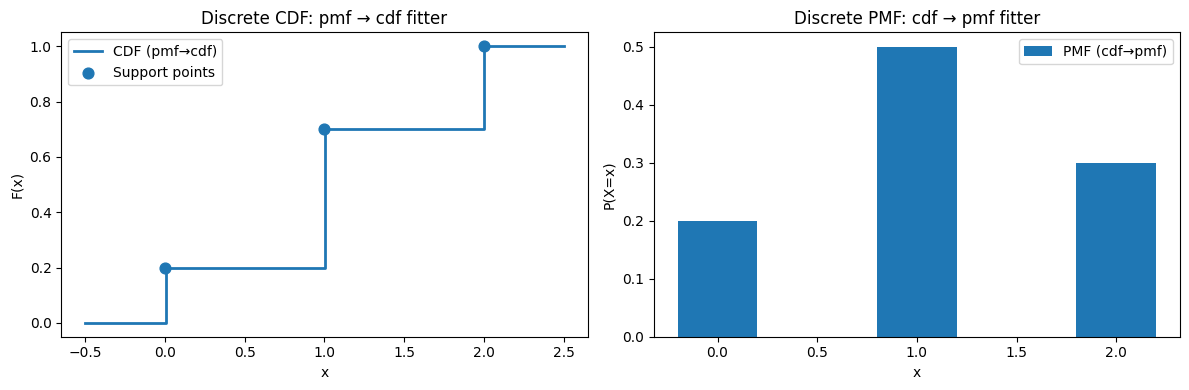

In [21]:
# 4.5  Visualisation: discrete CDF and PMF

xs_plot = np.linspace(-0.5, 2.5, 500)
cdf_plot = np.asarray(fitted_cdf_1D(xs_plot), dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Step-function CDF
axes[0].step(xs_plot, cdf_plot, where="post", lw=2, label="CDF (pmf→cdf)")
axes[0].scatter([0, 1, 2], [0.2, 0.7, 1.0], zorder=5, s=60, label="Support points")
axes[0].set_title("Discrete CDF: pmf → cdf fitter")
axes[0].set_xlabel("x")
axes[0].set_ylabel("F(x)")
axes[0].legend()

# PMF bars
axes[1].bar([0, 1, 2], [0.2, 0.5, 0.3], width=0.4, label="PMF (cdf→pmf)")
axes[1].set_title("Discrete PMF: cdf → pmf fitter")
axes[1].set_xlabel("x")
axes[1].set_ylabel("P(X=x)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. FitterRegistry

`FitterRegistry` stores `FitterDescriptor` objects and selects the best match
for a given `(target, sources, required_tags)` query.

The module-level `fitter_registry()` returns a **process-wide singleton** populated
lazily on first access with all built-in continuous and discrete descriptors.

In [22]:
# Inspect the built-in singleton registry
reg = fitter_registry()
print(f"Total registered descriptors: {len(reg)}")
print()

for desc in reg.all_descriptors():
    print(
        f"  {desc.name!r:30s}  {list(desc.sources)} -> {desc.target!r}  tags={desc.constraint_tags}"
    )

Total registered descriptors: 8

  'pdf_to_cdf_1C'                 [<CharacteristicName.PDF: 'pdf'>] -> <CharacteristicName.CDF: 'cdf'>  tags=frozenset({'univariate', 'continuous'})
  'cdf_to_pdf_1C'                 [<CharacteristicName.CDF: 'cdf'>] -> <CharacteristicName.PDF: 'pdf'>  tags=frozenset({'univariate', 'continuous'})
  'cdf_to_ppf_1C'                 [<CharacteristicName.CDF: 'cdf'>] -> <CharacteristicName.PPF: 'ppf'>  tags=frozenset({'univariate', 'continuous'})
  'ppf_to_cdf_1C'                 [<CharacteristicName.PPF: 'ppf'>] -> <CharacteristicName.CDF: 'cdf'>  tags=frozenset({'univariate', 'continuous'})
  'pmf_to_cdf_1D'                 [<CharacteristicName.PMF: 'pmf'>] -> <CharacteristicName.CDF: 'cdf'>  tags=frozenset({'discrete', 'univariate'})
  'cdf_to_pmf_1D'                 [<CharacteristicName.CDF: 'cdf'>] -> <CharacteristicName.PMF: 'pmf'>  tags=frozenset({'discrete', 'univariate'})
  'cdf_to_ppf_1D'                 [<CharacteristicName.CDF: 'cdf'>] -> <Chara

In [23]:
# Find a specific fitter by target + sources + required tags

desc_cont = reg.find(
    target=CharacteristicName.PPF,
    sources=[CharacteristicName.CDF],
    required_tags=frozenset({"continuous", "univariate"}),
)
print(f"Continuous CDF->PPF fitter: {desc_cont.name!r}")
print(f"  options: {desc_cont.option_names()}")

desc_disc = reg.find(
    target=CharacteristicName.PPF,
    sources=[CharacteristicName.CDF],
    required_tags=frozenset({"discrete", "univariate"}),
)
print(f"\nDiscrete CDF->PPF fitter: {desc_disc.name!r}")
print(f"  options: {desc_disc.option_names()}")

# find_all returns every matching descriptor in registration order
all_ppf = reg.find_all(target=CharacteristicName.PPF, sources=[CharacteristicName.CDF])
print(f"\nAll CDF->PPF fitters: {[d.name for d in all_ppf]}")

Continuous CDF->PPF fitter: 'cdf_to_ppf_1C'
  options: ('eps', 'x0', 'max_iter', 'x_tol')

Discrete CDF->PPF fitter: 'cdf_to_ppf_1D'
  options: ()

All CDF->PPF fitters: ['cdf_to_ppf_1C', 'cdf_to_ppf_1D']


In [24]:
# Custom registry: register your own fitter alongside the built-ins

custom_reg = FitterRegistry()

my_desc = FitterDescriptor(
    name="my_pdf_to_cdf",
    target=CharacteristicName.CDF,
    sources=[CharacteristicName.PDF],
    fitter=_fit_pdf_to_cdf_1C,  # reuse built-in fitter function
    computation_options=(
        ComputationOption(
            name="limit",
            type=int,
            default=50,
            description="Custom quad limit.",
            validate=lambda v: v > 0,
        ),
    ),
    constraint_tags=frozenset({"continuous", "univariate", "my_custom_tag"}),
    description="My custom pdf->cdf fitter with a lower default limit.",
)

custom_reg.register(my_desc)
print(f"Custom registry size: {len(custom_reg)}")
print(f"'my_pdf_to_cdf' in registry: {'my_pdf_to_cdf' in custom_reg}")

found = custom_reg.find(
    CharacteristicName.CDF,
    [CharacteristicName.PDF],
    required_tags=frozenset({"my_custom_tag"}),
)
print(f"Found by custom tag: {found.name!r}")

Custom registry size: 1
'my_pdf_to_cdf' in registry: True
Found by custom tag: 'my_pdf_to_cdf'


## 6. End-to-end: Distribution + ComputationStrategy

`DefaultComputationStrategy` is the engine that ties everything together.
When you call `distribution.query_method("ppf")`, the strategy:

1. Checks if the distribution has an analytical `ppf` — if yes, returns it directly.
2. Otherwise, walks the **characteristic graph** to find a conversion path from an
   analytical characteristic to `ppf`.
3. Fits each edge along the path (calling the appropriate fitter) and chains the results.

The strategy is attached to the distribution at construction time.

In [25]:
# End-to-end: distribution with only PDF, querying PPF via pdf->cdf->ppf chain


def normal_pdf_arr(x, **_):
    x = np.asarray(x, dtype=float)
    return np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)


# Distribution knows only PDF; strategy will derive CDF and PPF automatically
normal_pdf_only = SimpleDistribution(
    kind=Kind.CONTINUOUS,
    analytical_computations={CharacteristicName.PDF: wrap(CharacteristicName.PDF, normal_pdf_arr)},
    support=ContinuousSupport(),
)

# Query PPF — triggers pdf->cdf->ppf chain
ppf_method = normal_pdf_only.query_method(CharacteristicName.PPF)

qs = np.array([0.025, 0.16, 0.5, 0.84, 0.975])
ppf_vals = np.asarray(ppf_method(qs), dtype=float)

print("Normal distribution: PPF derived from PDF only")
print(f"  q          = {qs}")
print(f"  PPF(q)     = {ppf_vals.round(3)}")
print("  expected   ≈ [-1.96, -1.0, 0.0, 1.0, 1.96]")

Normal distribution: PPF derived from PDF only
  q          = [0.025 0.16  0.5   0.84  0.975]
  PPF(q)     = [-1.96  -0.994  0.     0.994  1.96 ]
  expected   ≈ [-1.96, -1.0, 0.0, 1.0, 1.96]


In [26]:
# calculate_characteristic: convenience wrapper around query_method

cdf_val = normal_pdf_only.calculate_characteristic(
    CharacteristicName.CDF, np.array([0.0, 1.0, -1.0])
)
print("CDF derived from PDF:")
print(f"  CDF([0, 1, -1]) = {np.asarray(cdf_val, dtype=float).round(4)}")
print("  expected        ≈ [0.5, 0.8413, 0.1587]")

CDF derived from PDF:
  CDF([0, 1, -1]) = [0.5    0.8413 0.1587]
  expected        ≈ [0.5, 0.8413, 0.1587]


## 7. Introspection with `explain_computation_path`

`distribution.explain_computation_path(characteristic)` returns a `ComputationPlan`
that describes **exactly** which steps the strategy will take, without performing any fitting.

This is useful for:
- Understanding which fitters will be used
- Discovering which options are available at each step
- Building per-step option overrides with `plan.with_options(step_index, **kwargs)`

In [27]:
# Introspect the computation path for PPF on a PDF-only distribution

plan = normal_pdf_only.explain_computation_path(CharacteristicName.PPF)

print(f"Target: {plan.target!r}")
print(f"Source: {plan.source!r}")
print(f"Steps:  {len(plan.steps)}")
print()

for i, step in enumerate(plan.steps):
    print(f"  Step {i}: {list(step.sources)} -> {step.target!r}")
    print(f"    edge_kind   = {step.edge_kind!r}")
    print(f"    method_name = {step.method_name!r}")
    char_opts = [o.name for o in step.options_descriptor.characteristic_options]
    comp_opts = [o.name for o in step.options_descriptor.computation_options]
    print(f"    char_opts   = {char_opts}")
    print(f"    comp_opts   = {comp_opts}")
    print()

print("All required options:", plan.required_options())
print("Characteristic options:", plan.required_characteristic_options())
print("Computation options:", plan.required_computation_options())

Target: <CharacteristicName.PPF: 'ppf'>
Source: <CharacteristicName.PDF: 'pdf'>
Steps:  2

  Step 0: [<CharacteristicName.PDF: 'pdf'>] -> <CharacteristicName.CDF: 'cdf'>
    edge_kind   = 'computation'
    method_name = 'pdf_to_cdf_1C'
    char_opts   = []
    comp_opts   = ['limit']

  Step 1: [<CharacteristicName.CDF: 'cdf'>] -> <CharacteristicName.PPF: 'ppf'>
    edge_kind   = 'computation'
    method_name = 'cdf_to_ppf_1C'
    char_opts   = ['eps', 'x0']
    comp_opts   = ['max_iter', 'x_tol']

All required options: ('limit', 'eps', 'x0', 'max_iter', 'x_tol')
Characteristic options: ('eps', 'x0')
Computation options: ('limit', 'max_iter', 'x_tol')


In [28]:
# Build per-step options using plan.with_options()
# This validates values eagerly and returns a StepOptions mapping.

plan = normal_pdf_only.explain_computation_path(CharacteristicName.PPF)

# Find the step that has 'eps' as a characteristic option
for i, step in enumerate(plan.steps):
    char_opt_names = [o.name for o in step.options_descriptor.characteristic_options]
    if "eps" in char_opt_names:
        print(f"Step {i} ({step.method_name!r}) has 'eps' option")
        # Set eps=1e-4 for this step (changes effective support bounds)
        step_opts = plan.with_options(i, eps=1e-4)
        print(f"  step_opts = {step_opts}")
        break

# Query PPF with custom options
ppf_custom = normal_pdf_only.query_method(CharacteristicName.PPF, options=step_opts)
qs = np.array([0.1, 0.5, 0.9])
print(f"\nPPF with eps=1e-4: {np.asarray(ppf_custom(qs), dtype=float).round(4)}")

Step 1 ('cdf_to_ppf_1C') has 'eps' option
  step_opts = {1: ResolvedEdgeOptions(descriptor=EdgeOptionsDescriptor(name='cdf_to_ppf_1C', characteristic_options=(CharacteristicOption(name='eps', type=<class 'float'>, default=1e-06, description='Tail probability threshold for support bound estimation.  Affects the effective domain of the PPF — different values yield a different result.', validate=<function _build_cdf_to_ppf_1C.<locals>.<lambda> at 0x1167b3060>), CharacteristicOption(name='x0', type=<class 'float'>, default=0.0, description='Starting point for exponential bound search.  Affects which support bounds are discovered.', validate=None)), computation_options=(ComputationOption(name='max_iter', type=<class 'int'>, default=60, description='Maximum bisection iterations.', validate=<function _build_cdf_to_ppf_1C.<locals>.<lambda> at 0x1167b3100>), ComputationOption(name='x_tol', type=<class 'float'>, default=1e-10, description='Early-stop tolerance on bracket width.', validate=<funct

## 8. Caching and performance

`DefaultComputationStrategy(enable_caching=True)` caches fitted computation methods
so that repeated calls to `query_method` for the same `(distribution, characteristic, options)`
do not re-run the expensive fitting step.

Cache key = `(id(distribution), id(edge), target, frozen_options)`.

**CharacteristicOptions** are part of the cache key (different values → different entries).
**ComputationOptions** are also part of the cache key (they affect fitting accuracy).

In [29]:
# Compare: no caching vs caching


def make_pdf_only_distr():
    def pdf(x, **_):
        x = np.asarray(x, dtype=float)
        return np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)

    return SimpleDistribution(
        kind=Kind.CONTINUOUS,
        analytical_computations={CharacteristicName.PDF: wrap(CharacteristicName.PDF, pdf)},
        support=ContinuousSupport(),
        computation_strategy=DefaultComputationStrategy(enable_caching=True),
    )


distr_cached = make_pdf_only_distr()

# First call: fitting happens
t0 = time.perf_counter()
ppf1 = distr_cached.query_method(CharacteristicName.PPF)
t1 = time.perf_counter()
print(f"First call  (fitting):  {(t1-t0)*1000:.1f} ms")

# Second call: served from cache
t0 = time.perf_counter()
ppf2 = distr_cached.query_method(CharacteristicName.PPF)
t1 = time.perf_counter()
print(f"Second call (cached):   {(t1-t0)*1000:.1f} ms")

# Both return the same result
qs = np.array([0.1, 0.5, 0.9])
print(f"\nResults match: {np.allclose(ppf1(qs), ppf2(qs))}")

First call  (fitting):  1.9 ms
Second call (cached):   0.1 ms

Results match: True


In [30]:
# CharacteristicOptions produce separate cache entries

distr_cached2 = make_pdf_only_distr()

# Query PPF with eps=1e-4 (first entry)
plan = distr_cached2.explain_computation_path(CharacteristicName.PPF)
for i, step in enumerate(plan.steps):
    if "eps" in [o.name for o in step.options_descriptor.characteristic_options]:
        opts_a = plan.with_options(i, eps=1e-4)
        opts_b = plan.with_options(i, eps=1e-7)
        break

ppf_a = distr_cached2.query_method(CharacteristicName.PPF, options=opts_a)
ppf_b = distr_cached2.query_method(CharacteristicName.PPF, options=opts_b)

qs = np.array([0.1, 0.5, 0.9])
print("PPF with eps=1e-4:", np.asarray(ppf_a(qs), dtype=float).round(5))
print("PPF with eps=1e-7:", np.asarray(ppf_b(qs), dtype=float).round(5))
print("(Different eps -> different cache entries -> slightly different results near tails)")

PPF with eps=1e-4: [-1.28155  0.       1.28155]
PPF with eps=1e-7: [-1.28155  0.       1.28155]
(Different eps -> different cache entries -> slightly different results near tails)


## 9. Custom fitter descriptor

`FitterDescriptor` is the full metadata wrapper for a fitter.
It combines the fitter callable with option declarations, constraint tags, and a description.

Use it when you want to:
- Register a custom fitter in a `FitterRegistry`
- Expose it to the strategy's automatic path-finding
- Provide rich introspection (option names, defaults, descriptions)

In [31]:
# Custom fitter: CDF -> PPF via Newton-Raphson (requires both CDF and PDF)
# This is a toy example to illustrate the descriptor pattern.

from pysatl_core.distributions.computations._utils import resolve


def _fit_cdf_pdf_to_ppf_newton(distribution, /, max_iter=50, tol=1e-10, eps=1e-6, x0=0.0):
    """PPF via Newton-Raphson: x_{n+1} = x_n - (CDF(x_n) - q) / PDF(x_n)."""
    cdf_fn = resolve(distribution, CharacteristicName.CDF)
    pdf_fn = resolve(distribution, CharacteristicName.PDF)

    def _ppf(q, **opts):
        q_arr = np.atleast_1d(np.asarray(q, dtype=float))
        result = np.full_like(q_arr, np.nan)
        result[q_arr <= 0.0] = -np.inf
        result[q_arr >= 1.0] = np.inf
        interior = (q_arr > 0.0) & (q_arr < 1.0)
        if np.any(interior):
            q_in = q_arr[interior]
            x = np.full_like(q_in, x0)
            for _ in range(max_iter):
                cdf_x = np.asarray(cdf_fn(x), dtype=float)
                pdf_x = np.asarray(pdf_fn(x), dtype=float)
                pdf_x = np.where(np.abs(pdf_x) < 1e-300, 1e-300, pdf_x)
                dx = (cdf_x - q_in) / pdf_x
                x = x - dx
                if np.max(np.abs(dx)) < tol:
                    break
            result[interior] = x
        return result

    return FittedComputationMethod(
        target=CharacteristicName.PPF,
        sources=[CharacteristicName.CDF, CharacteristicName.PDF],
        func=_ppf,
    )


newton_descriptor = FitterDescriptor(
    name="cdf_pdf_to_ppf_newton",
    target=CharacteristicName.PPF,
    sources=[CharacteristicName.CDF, CharacteristicName.PDF],
    fitter=_fit_cdf_pdf_to_ppf_newton,
    characteristic_options=(
        CharacteristicOption(
            name="eps",
            type=float,
            default=1e-6,
            description="Tail threshold.",
            validate=lambda v: 0 < v < 0.5,
        ),
        CharacteristicOption(
            name="x0", type=float, default=0.0, description="Starting point for Newton iterations."
        ),
    ),
    computation_options=(
        ComputationOption(
            name="max_iter",
            type=int,
            default=50,
            description="Max Newton iterations.",
            validate=lambda v: v > 0,
        ),
        ComputationOption(
            name="tol",
            type=float,
            default=1e-10,
            description="Convergence tolerance.",
            validate=lambda v: v > 0,
        ),
    ),
    constraint_tags=frozenset({"continuous", "univariate"}),
    description="PPF via Newton-Raphson using both CDF and PDF.",
)

In [32]:
# Use the custom Newton fitter directly on the logistic distribution
# (logistic has both CDF and PDF available analytically)


def logistic_pdf_arr(x, **_):
    x = np.asarray(x, dtype=float)
    return np.exp(-x) / (1.0 + np.exp(-x)) ** 2


logistic_both = SimpleDistribution(
    kind=Kind.CONTINUOUS,
    analytical_computations={
        CharacteristicName.CDF: wrap(CharacteristicName.CDF, logistic_cdf),
        CharacteristicName.PDF: wrap(CharacteristicName.PDF, logistic_pdf_arr),
    },
    support=ContinuousSupport(),
)

# Fit the custom descriptor
fitted_newton = newton_descriptor.to_computation_method().fit(logistic_both)

qs = np.array([0.1, 0.25, 0.5, 0.75, 0.9])
ppf_newton = np.asarray(fitted_newton(qs), dtype=float)
ppf_exact = np.log(qs / (1.0 - qs))

print("Newton PPF vs analytical (Logistic):")
print(f"  Newton   = {ppf_newton.round(6)}")
print(f"  Exact    = {ppf_exact.round(6)}")
print(f"  max err  = {np.abs(ppf_newton - ppf_exact).max():.2e}")

Newton PPF vs analytical (Logistic):
  Newton   = [-2.197225 -1.098612  0.        1.098612  2.197225]
  Exact    = [-2.197225 -1.098612  0.        1.098612  2.197225]
  max err  = 4.44e-16
